# 04 — Diskriminanz-Analyse & Feature-Selektion

**Phase 4 des SPI-Extra-Pipelines:** Statistische Tests (ANOVA / Kruskal-Wallis), paarweise Post-hoc-Tests (Dunn), Effektstärken, Multikollinearität (Korrelation, VIF), ML-basierte Wichtigkeit (Random Forest, SHAP, RFECV) sowie **gruppenspezifische** Kandidatenmerkmale (Winners / Steady / Losers).

**Voraussetzung:** OHLCV- und Fundamental-Cache wie in Notebook 01/03; Features basieren ausschließlich auf Daten *vor* Q1 2024 (`config.FEATURE_CUTOFF_DATE`) — kein Lookahead auf die Klassifikationsperiode.

In [1]:
from __future__ import annotations

import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.analysis import (
    anova_by_group,
    correlation_matrix,
    compute_vif,
    effect_sizes,
    full_analysis_report,
    plot_feature_boxplots,
    plot_feature_violins,
    plot_importance_bar,
    plot_radar_chart,
    posthoc_pairwise,
    rf_feature_importance,
)
from src.classifier import assign_groups, compute_q1_returns
from src.data_loader import download_ohlcv, load_fundamentals
from src.features import (
    FUNDAMENTAL_FEATURE_NAMES,
    TECHNICAL_FEATURE_NAMES,
    build_feature_matrix,
)
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)

## Daten laden (wie Notebook 03)

Universum, optional `TICKER_LIMIT` für schnelle Läufe, OHLCV-Cache, Liquiditätsfilter, Fundamentals, dann `build_feature_matrix` mit Stichtag vor Q1 2024. Labels aus Q1-2024-Totalreturn (Perzentil-Methode).

In [2]:
# None = alle SPI-Extra-Ticker; z. B. 40 für einen schnellen Smoke-Test
TICKER_LIMIT: int | None = None

all_tickers = get_spi_extra_tickers()
tickers = all_tickers if TICKER_LIMIT is None else all_tickers[:TICKER_LIMIT]

cache_dir = config.ensure_data_dir()
FORCE_REFRESH = False

ohlcv_by_ticker = download_ohlcv(
    tickers,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=cache_dir,
    force_refresh=FORCE_REFRESH,
    max_workers=8,
    retries=2,
)

if not ohlcv_by_ticker:
    raise RuntimeError(
        "Keine OHLCV-Daten — Netzwerk prüfen oder Notebook 01 einmal ausführen."
    )

liquid_tickers = filter_by_min_volume(ohlcv_by_ticker, config.MIN_DAILY_VOLUME_CHF)
ohlcv_liquid = {t: ohlcv_by_ticker[t] for t in liquid_tickers if t in ohlcv_by_ticker}

if not ohlcv_liquid:
    warnings.warn(
        "Keine Ticker nach Liquiditätsfilter — es werden alle geladenen Serien verwendet.",
        stacklevel=1,
    )
    ohlcv_liquid = ohlcv_by_ticker


def _load_fund_batch(
    tickers: list[str], *, cache_dir: Path, max_workers: int = 6
) -> dict[str, dict]:
    out: dict[str, dict] = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {
            ex.submit(load_fundamentals, t, cache_dir=cache_dir, force_refresh=False): t
            for t in tickers
        }
        for fut in as_completed(futs):
            t = futs[fut]
            try:
                out[t] = fut.result()
            except Exception:
                out[t] = {}
    return out


ticker_list = list(ohlcv_liquid.keys())
fundamentals_by_ticker = _load_fund_batch(ticker_list, cache_dir=cache_dir)

feature_matrix = build_feature_matrix(
    ohlcv_liquid,
    cutoff_date=config.FEATURE_CUTOFF_DATE,
    fundamentals_by_ticker=fundamentals_by_ticker,
)

q1_returns = compute_q1_returns(
    ohlcv_liquid,
    q_start=config.CLASS_Q_START,
    q_end=config.CLASS_Q_END,
)
labels = assign_groups(q1_returns, method="percentile")

print(f"Projekt: {PROJECT_ROOT}")
print(f"Feature-Cutoff: {config.FEATURE_CUTOFF_DATE}")
print(
    f"OHLCV: {len(ohlcv_by_ticker)} Ticker, {len(ohlcv_liquid)} nach Liquiditätsfilter"
)
print(
    f"Feature-Matrix: {feature_matrix.shape[0]} × {feature_matrix.shape[1]} "
    f"(technisch {len(TECHNICAL_FEATURE_NAMES)}, fundamental {len(FUNDAMENTAL_FEATURE_NAMES)})"
)

$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$BALN.SW: possibly delisted; no timezone found

1 Failed download:
['BALN.SW']: possibly delisted; no timezone found
$BLS.SW: possibly delisted; no timezone found

1 Failed download:
['BLS.SW']: possibly delisted; no timezone found
$BOBNN.SW: possibly delisted; no timezone found

1 Failed download:
['BOBNN.SW']: possibly delisted; no timezone found
$BPDG.SW: possibly delisted; no timezone found

1 Fail

Projekt: /Users/stephangath/cursorAi/Stock Analysis AI
Feature-Cutoff: 2023-12-31
OHLCV: 154 Ticker, 136 nach Liquiditätsfilter
Feature-Matrix: 136 × 28 (technisch 18, fundamental 10)


## Feature-Matrix und Zielvariable

Nur Zeilen mit gültiger Gruppe; Spalten mit ausreichend Beobachtungen für Tests (mindestens ~5 % nicht-NaN oder mindestens 3 Werte).

In [3]:
X = feature_matrix.copy()
y = labels.reindex(X.index)

valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

min_nonna = max(3, int(0.05 * len(X)))
ok_cols = [c for c in X.columns if X[c].notna().sum() >= min_nonna]
X = X[ok_cols]

print(f"Analyse-Stichprobe: {len(X)} Aktien × {X.shape[1]} Features")
display(y.value_counts().reindex(["Winners", "Steady", "Losers"], fill_value=0))

Analyse-Stichprobe: 135 Aktien × 28 Features


Winners    34
Steady     67
Losers     34
Name: count, dtype: int64

## Gesamtbericht (`full_analysis_report`)

Führt nacheinander aus: Kruskal/ANOVA-Tabelle, Dunn-Post-hoc, Effektstärken, Korrelation, VIF, Random-Forest-Importance, optional SHAP und RFECV, sowie die heuristische Auswahl **gruppenspezifischer** Top-Features (`select_discriminative_features` in `src/analysis.py`).

> **Hinweis:** SHAP und RFECV können bei vielen Ticker etwas dauern.

In [4]:
report = full_analysis_report(
    X,
    y,
    run_shap=True,
    run_rfe=True,
    n_per_group=5,
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Omnibus-Tests (ANOVA F-Test, Kruskal-Wallis)

Für jedes Feature: unterscheiden sich die drei Gruppen gemeinsam? `kruskal_p_fdr` ist der Benjamini–Hochberg-korrigierte p-Wert über alle Features; `eta_squared` beschreibt die erklärte Varianz zwischen Gruppen.

In [5]:
anova_df = report["anova"]
key_cols = [
    c
    for c in anova_df.columns
    if c.startswith(("anova_", "kruskal_", "eta_")) or c in ("significant",)
]
desc_cols = [c for c in anova_df.columns if c.startswith(("mean_", "median_"))]
display(anova_df[key_cols + desc_cols].head(25))

,anova_f,anova_p,kruskal_h,kruskal_p,eta_squared,kruskal_p_fdr,significant,mean_Winners,median_Winners,mean_Steady,median_Steady,mean_Losers,median_Losers
feature,,,,,,,,,,,,,
atr_14_pct,9.677278,0.000120,17.924157,0.000128,0.127876,0.003589,True,0.032411,0.022865,0.018634,0.016605,0.024414,0.020685
dist_52w_low,11.441812,0.000026,15.950537,0.000344,0.147747,0.004814,True,0.443955,0.243809,0.157219,0.103448,0.185154,0.152419
profit_margin,2.884747,0.059426,12.988501,0.001512,0.042184,0.007846,True,0.052688,0.080640,0.233642,0.127380,0.059046,0.019480
hvol_60d,6.954351,0.001344,12.899899,0.001581,0.095325,0.007846,True,0.367160,0.277372,0.232153,0.201861,0.301096,0.250303
hvol_20d,6.922686,0.001383,12.898017,0.001582,0.094932,0.007846,True,0.365061,0.263818,0.213568,0.177989,0.269069,0.220424
debt_equity,4.866225,0.009622,12.776329,0.001681,0.088693,0.007846,True,34.848923,27.014000,56.030304,47.840500,143.750710,95.995000
mom_1m,5.205578,0.006668,8.214923,0.016449,0.073106,0.065798,False,0.083313,0.054633,0.029025,0.037037,0.032493,0.027215
bb_width,4.797358,0.009745,7.100131,0.028723,0.067762,0.100530,False,14.600884,10.927128,8.960996,7.717328,10.595542,9.688224
roe,0.752244,0.473412,6.555451,0.037714,0.011799,0.117332,False,0.110751,0.127970,0.053604,0.095880,0.012668,0.066990


Features mit Kruskal FDR < 0.05: 6 / 28


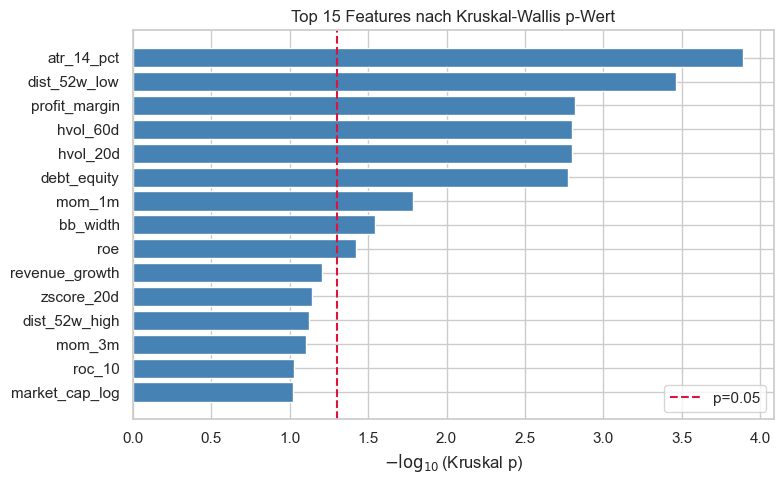

In [6]:
sig_n = int(anova_df["significant"].fillna(False).sum())
print(f"Features mit Kruskal FDR < 0.05: {sig_n} / {len(anova_df)}")

fig, ax = plt.subplots(figsize=(8, 5))
top_p = anova_df["kruskal_p"].replace(0, 1e-300).clip(lower=1e-300)
ax.barh(top_p.head(15).index[::-1], -np.log10(top_p.head(15)[::-1]), color="steelblue")
ax.axvline(-np.log10(0.05), color="crimson", ls="--", label="p=0.05")
ax.set_xlabel(r"$-\log_{10}$(Kruskal p)")
ax.set_title("Top 15 Features nach Kruskal-Wallis p-Wert")
ax.legend()
plt.tight_layout()
plt.show()

### Paarweise Post-hoc (Dunn) und Cohen's d

Welche Gruppenpaare unterscheiden sich pro Feature? `p_corrected` ist Bonferroni innerhalb des Features über die Paarvergleiche.

In [7]:
posthoc = report["posthoc"]
sig_pairs = posthoc[posthoc["significant"]].sort_values("p_corrected")
print(f"Signifikante Paarvergleiche (Dunn): {len(sig_pairs)}")
display(sig_pairs.head(30))

Signifikante Paarvergleiche (Dunn): 12


,feature,group_a,group_b,z_stat,p_raw,p_corrected,significant,cohens_d
30,atr_14_pct,Winners,Steady,4.089664,0.000043,0.000130,True,0.889306
48,dist_52w_low,Winners,Steady,3.980615,0.000069,0.000206,True,0.871166
79,debt_equity,Winners,Losers,-3.572176,0.000354,0.001062,True,-0.568377
77,profit_margin,Steady,Losers,3.551619,0.000383,0.001149,True,0.371677
24,hvol_20d,Winners,Steady,3.526563,0.000421,0.001263,True,0.748045
27,hvol_60d,Winners,Steady,3.335060,0.000853,0.002558,True,0.744591
33,bb_width,Winners,Steady,2.605614,0.009171,0.027513,True,0.614728
1,mom_1m,Winners,Losers,2.604241,0.009208,0.027623,True,0.499629
49,dist_52w_low,Winners,Losers,2.557725,0.010536,0.031608,True,0.662990
73,roe,Winners,Losers,2.538423,0.011135,0.033406,True,0.457212


### Effektstärken (η² omnibus, paarweise Cohen's d)

Große |d| (>0.8) deuten auf praktisch relevante Mittelwertsunterschiede; η² gibt die globale Gruppendifferenz pro Feature wieder.

In [8]:
effects = report["effects"]
display(effects.head(20))

,eta_squared,d_Winners_vs_Steady,d_Winners_vs_Losers,d_Steady_vs_Losers
feature,,,,
dist_52w_low,0.147747,0.871166,0.662990,-0.196937
atr_14_pct,0.127876,0.889306,0.405420,-0.592979
hvol_60d,0.095325,0.744591,0.314973,-0.496187
hvol_20d,0.094932,0.748045,0.399350,-0.389889
debt_equity,0.088693,-0.524869,-0.568377,-0.527979
mom_1m,0.073106,0.737253,0.499629,-0.044278
bb_width,0.067762,0.614728,0.393903,-0.238978
mom_3m,0.058887,0.579093,0.383680,-0.173595
dist_52w_high,0.053060,-0.468124,0.008401,0.557520


### Multikollinearität: Korrelation & VIF

Hohe Pearson-Korrelationen (>|0.8|) und VIF > 10 deuten auf Redundanz hin — für lineare Modelle oder Interpretation einzelner Koeffizienten sollten solche Features nicht gemeinsam verwendet werden; Tree-Modelle sind robuster, trotzdem lohnt sich Deduplikation.

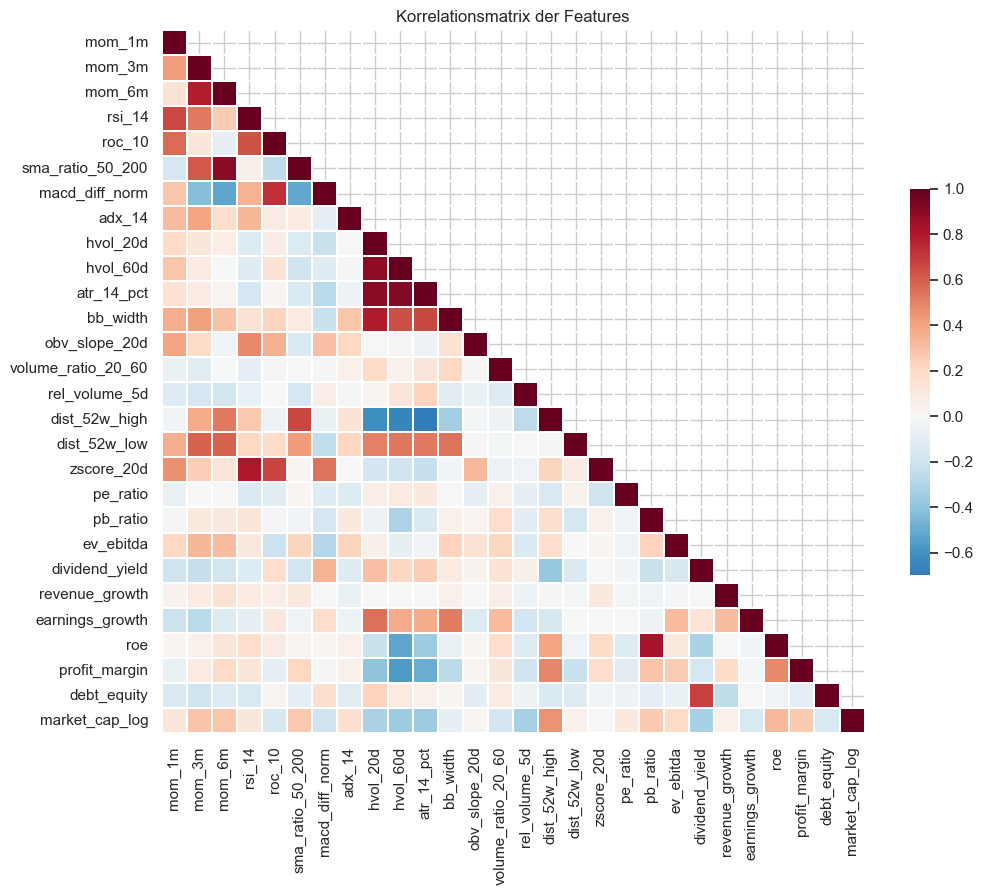

,feature,vif,collinear
0,sma_ratio_50_200,25.870593,True
1,hvol_20d,22.742271,True
2,hvol_60d,20.456128,True
3,atr_14_pct,20.011235,True
4,mom_6m,19.051132,True
5,macd_diff_norm,15.337893,True
6,dist_52w_high,10.516838,True
7,mom_3m,9.013868,False
8,roc_10,8.944669,False
9,rsi_14,8.493820,False


In [9]:
corr = report["correlation"]
if corr.shape[0] > 1:
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    plt.figure(figsize=(11, 9))
    sns.heatmap(
        corr,
        mask=mask,
        cmap="RdBu_r",
        center=0,
        square=True,
        linewidths=0.2,
        cbar_kws={"shrink": 0.55},
    )
    plt.title("Korrelationsmatrix der Features")
    plt.tight_layout()
    plt.show()
else:
    print("Zu wenige Spalten für Korrelations-Heatmap.")

vif_df = report["vif"]
display(vif_df.head(15))

### Random Forest: Gini-Importance

Klassengewichtung `balanced`; Importance misst mittlere Unreinheitsreduktion — gut für Ranking, aber nicht für Kausalität.

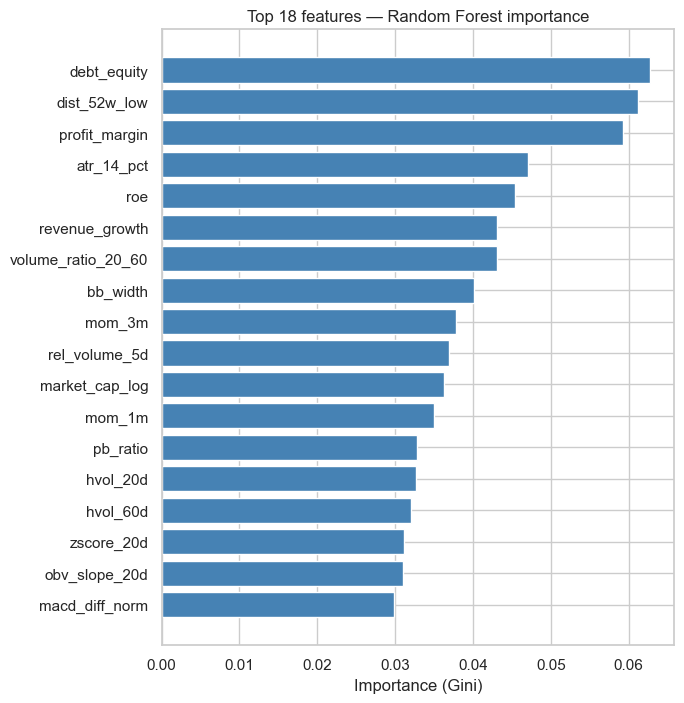

In [10]:
rf_imp = report["rf_importance"]
ax = plot_importance_bar(rf_imp, top_n=min(18, len(rf_imp)))
plt.show()

### SHAP (mittlere |Beiträge| pro vorhergesagter Klasse)

Zeigt, welche Features das Modell für die Trennung *Winners* vs *Steady* vs *Losers* nutzt — gruppenbezogen über die SHAP-Achse der jeweiligen Klasse.

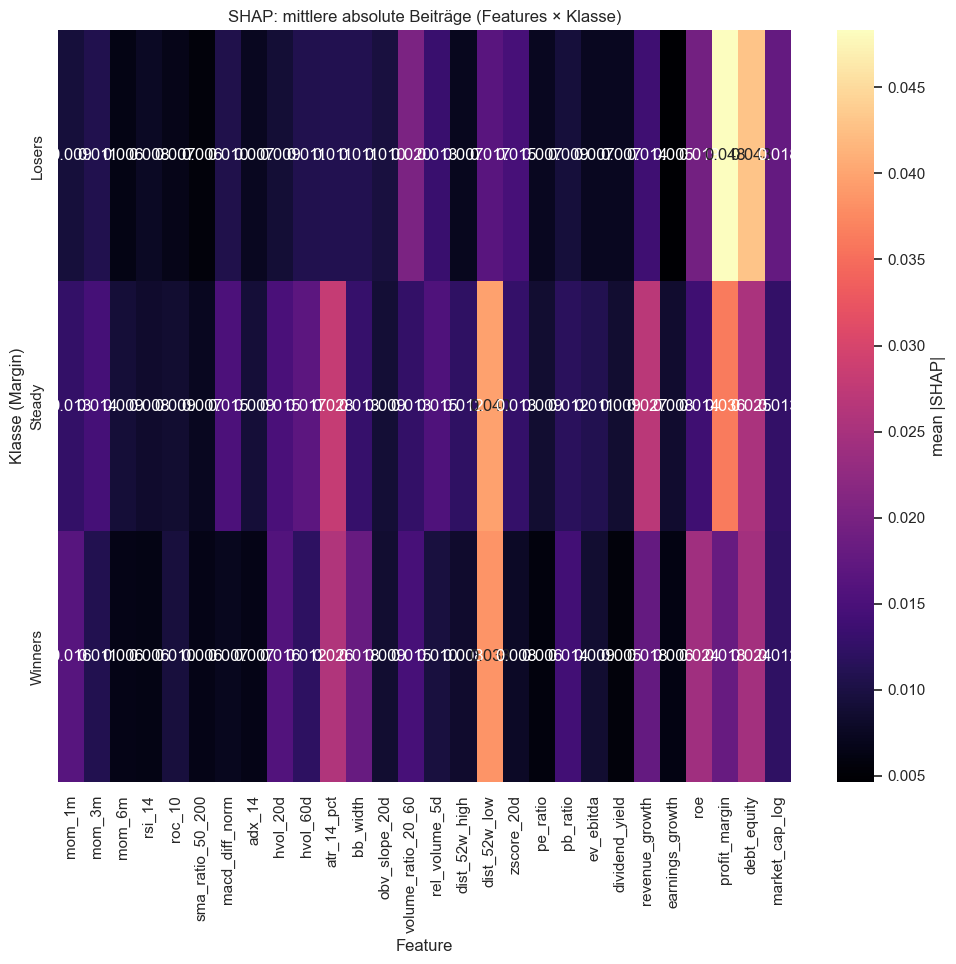

In [11]:
shap_pack = report.get("shap")
if shap_pack is not None:
    mean_abs = shap_pack["mean_abs_shap"]
    plt.figure(figsize=(10, max(4, 0.35 * len(mean_abs))))
    sns.heatmap(
        mean_abs.T,
        annot=True,
        fmt=".3f",
        cmap="magma",
        cbar_kws={"label": "mean |SHAP|"},
    )
    plt.title("SHAP: mittlere absolute Beiträge (Features × Klasse)")
    plt.xlabel("Feature")
    plt.ylabel("Klasse (Margin)")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP nicht verfügbar (Abhängigkeit oder Fehler beim Lauf).")

### RFECV — rekursive Merkmalselimination mit Kreuzvalidierung

Sucht eine kompakte Feature-Teilmenge mit hohem macro-F1 unter stratifizierten Folds.

In [12]:
rfe = report.get("rfe")
if rfe is not None:
    print(f"Optimale Feature-Anzahl: {rfe['n_features_optimal']}")
    display(rfe["ranking"].head(30))
    print("Ausgewählte Features:", rfe["selected_features"])
else:
    print("RFECV nicht verfügbar.")

Optimale Feature-Anzahl: 9


,feature,rank,selected
0,mom_1m,1,True
1,mom_3m,1,True
25,profit_margin,1,True
24,roe,1,True
22,revenue_growth,1,True
16,dist_52w_low,1,True
26,debt_equity,1,True
10,atr_14_pct,1,True
8,hvol_20d,1,True
27,market_cap_log,2,False


Ausgewählte Features: ['mom_1m', 'mom_3m', 'profit_margin', 'roe', 'revenue_growth', 'dist_52w_low', 'debt_equity', 'atr_14_pct', 'hvol_20d']


### Gruppenspezifische Top-Features

Heuristik in `select_discriminative_features`: kombiniert paarweise Effektstärken (Dunn/Cohen) mit RF-Importance und bevorzugt Diversität zwischen Gruppen — Ziel: **3–5 interpretierbare** Kandidaten pro Gruppe für Notebook 05.

In [13]:
selected = report["selected"]
for grp, feats in selected.items():
    print(f"{grp}: {feats}")

Winners: ['dist_52w_low', 'mom_1m', 'atr_14_pct', 'hvol_20d', 'debt_equity']
Steady: ['atr_14_pct', 'hvol_60d', 'hvol_20d', 'dist_52w_low', 'bb_width']
Losers: ['debt_equity', 'atr_14_pct', 'dist_52w_low', 'roe', 'zscore_20d']


## Visualisierungen: Verteilungen & Profil

Box- und Violinplots für eine **kompakte** Feature-Liste (Top nach Kruskal + gruppenspezifische Auswahl). Radar: standardisierte Gruppen-Medianwerte auf einer überschaubaren Merkmalsmenge (sonst überladen).

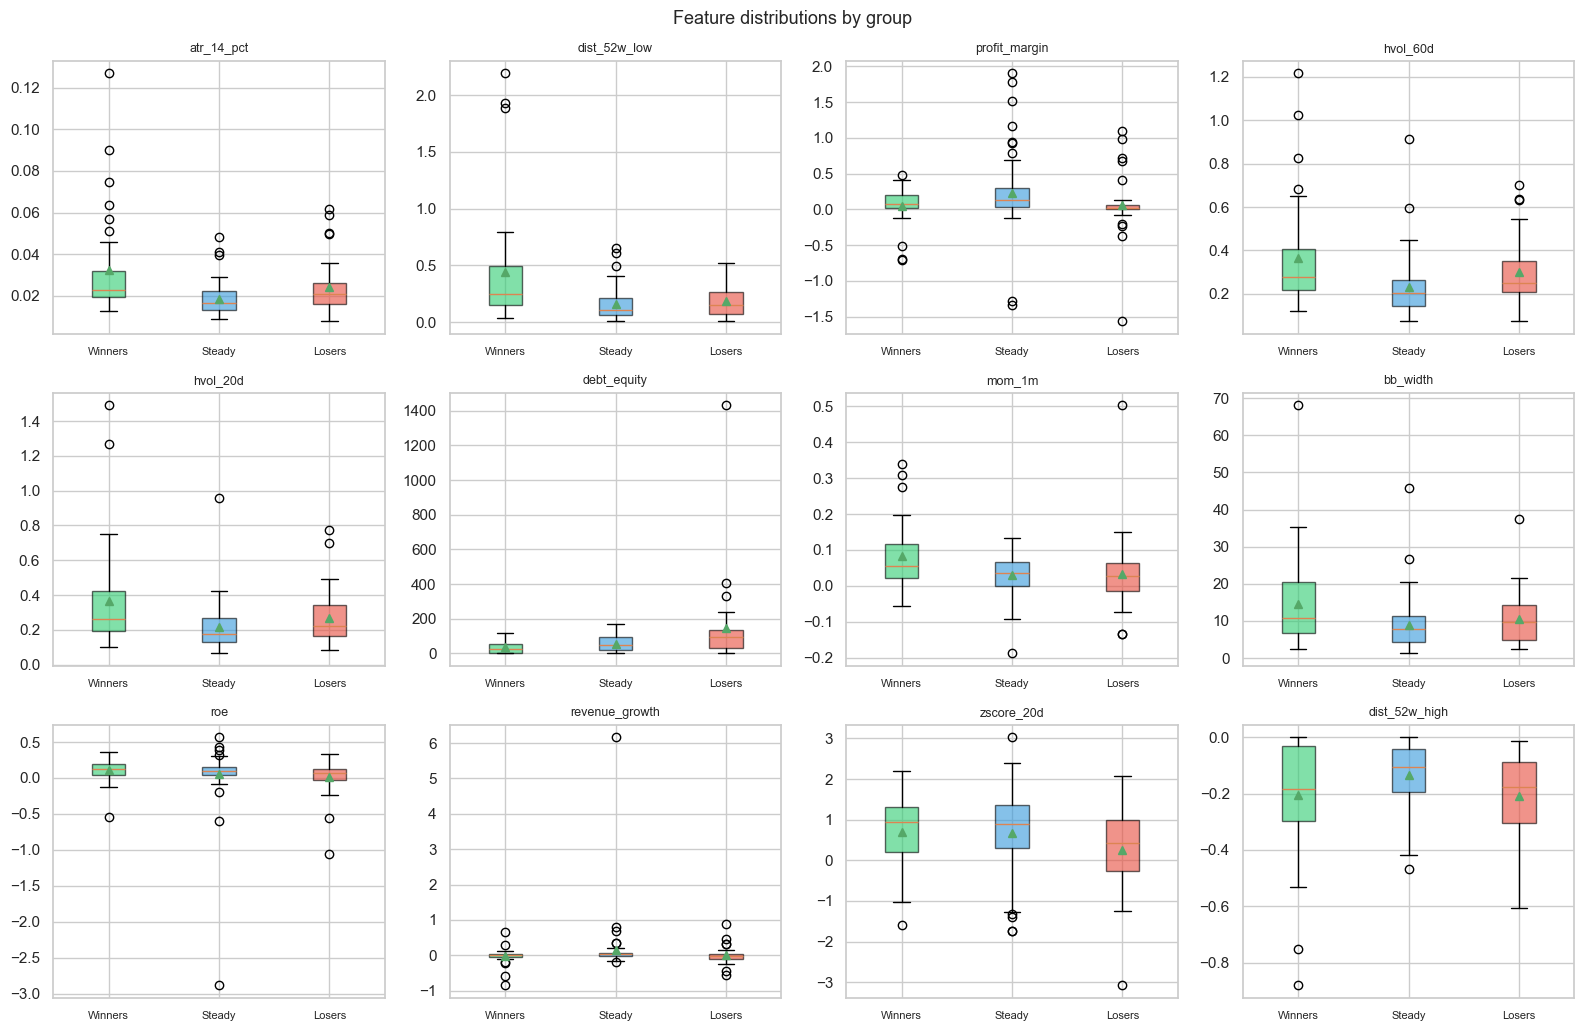

In [14]:
top_k = 12
top_anova = anova_df.head(top_k).index.tolist()
seen: list[str] = []
for feats in selected.values():
    for f in feats:
        if f not in seen:
            seen.append(f)
plot_cols = list(dict.fromkeys(top_anova + seen))[:20]

fig = plot_feature_boxplots(X, y, feature_names=plot_cols, ncols=4)
plt.show()

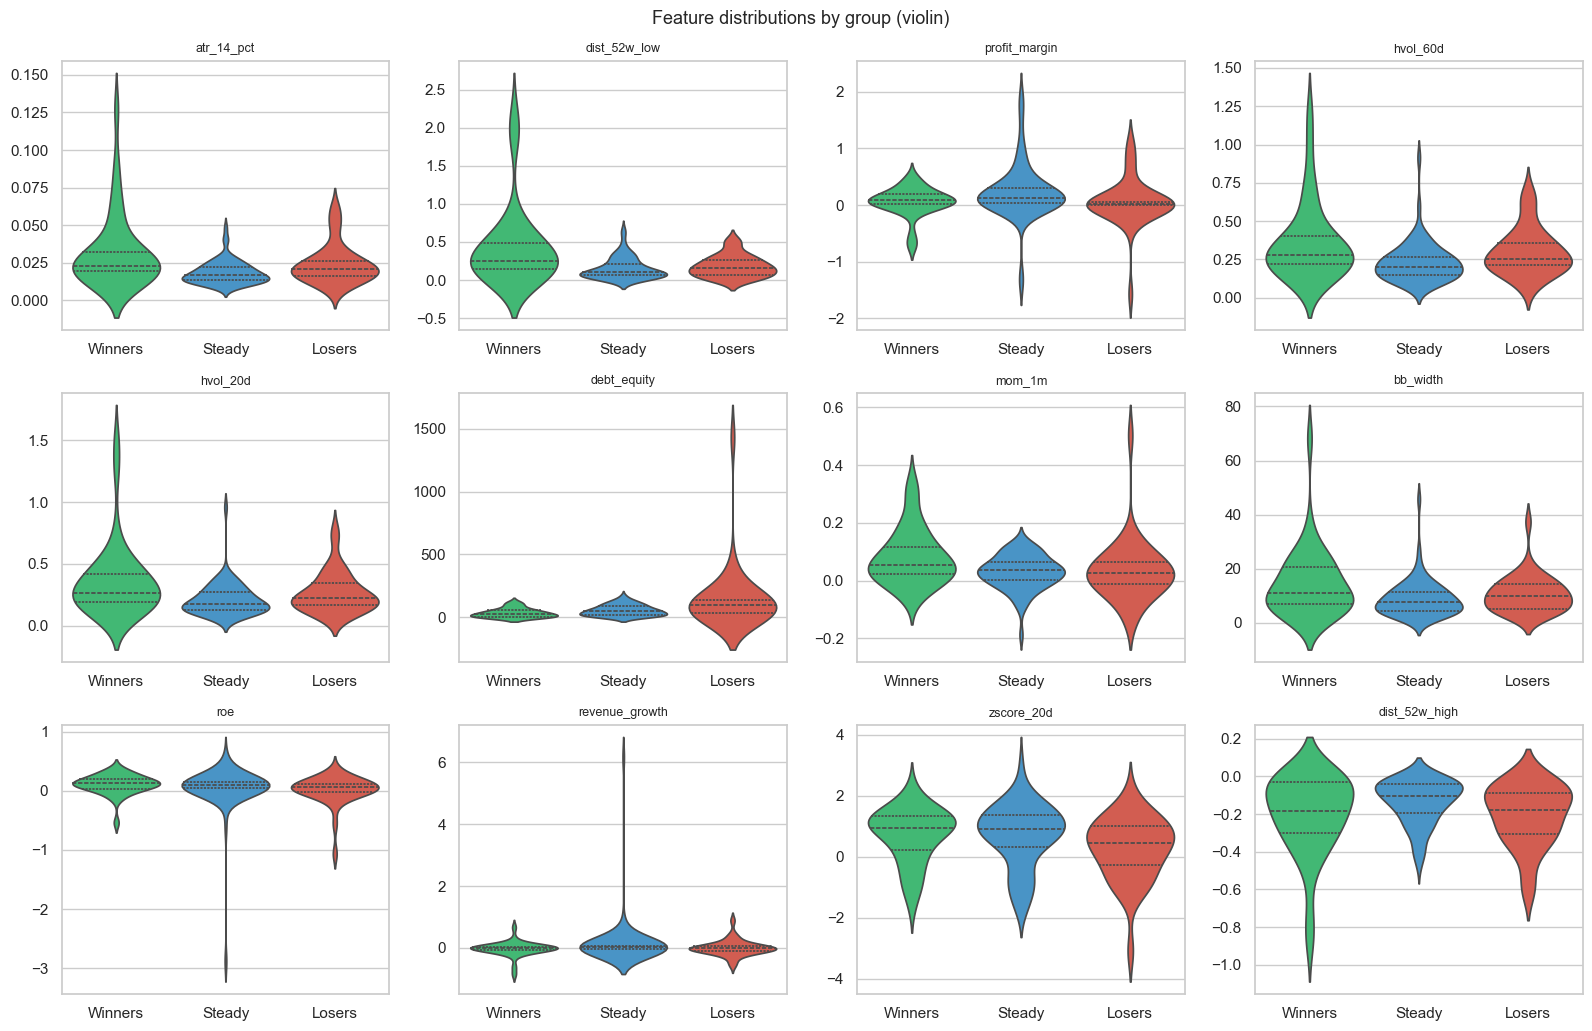

In [15]:
fig = plot_feature_violins(X, y, feature_names=plot_cols[: min(12, len(plot_cols))], ncols=4)
plt.show()

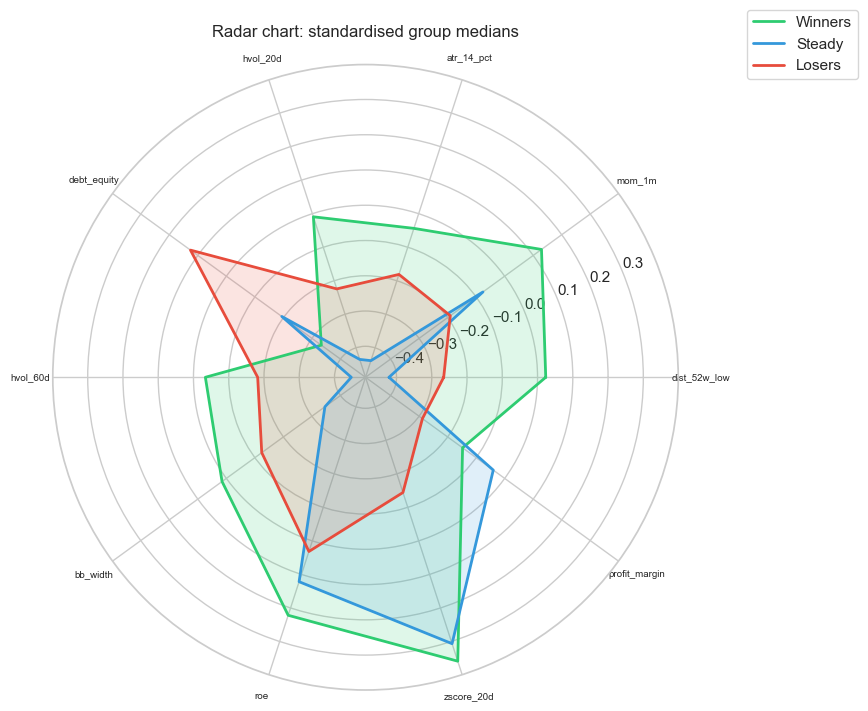

In [16]:
radar_feats = list(dict.fromkeys(seen + top_anova[:6]))[:10]
fig = plot_radar_chart(X, y, feature_names=radar_feats, figsize=(9, 9))
plt.show()

## Interpretation (Leseleitfaden)

1. **Omnibus vs. Paarvergleiche:** Ein niedriges Kruskal-*p* bedeutet nur, dass *irgendwo* Gruppen sich unterscheiden. Die Dunn-Tabelle zeigt *welche* Paare (Winners–Losers, Winners–Steady, …) — ohne signifikante Paare ist das Feature für Gruppentrennung wenig aussagekräftig.
2. **Effektstärke:** Statistische Signifikanz bei vielen Ticker leicht erreichbar; Cohen's *d* und η² zeigen, ob Unterschiede **praktisch** relevant sind.
3. **VIF / Korrelation:** Redundante Features verzerren nicht die Tree-Modelle stark, erhöhen aber die Varianz der Interpretation — für ein schlankes Modell Features mit hoher Korrelation und niedriger Zusatzinfo streichen.
4. **RF vs. SHAP:** Gini-Importance ist schnell, aber durch Skalen und Korrelation verzerrt. SHAP ordnet jedem Merkmal einen Beitrag pro Klasse zu — nützlich, um zu sehen, ob ein Signal eher *Winners* oder *Losers* trägt.
5. **Gruppenspezifische Liste:** Die automatisch gewählten Top-Features pro Gruppe sind **Kandidaten** für Notebook 05; plausibel machen Sie diese im Kontext (z. B. Momentum vs. Bewertung) und prüfen Sie Stabilität bei anderem `TICKER_LIMIT`.
6. **Overfitting-Warnung:** Gute Diskriminanz in Q1 2024 garantiert keine Out-of-Sample-Performance (2025) — Notebook 06 vergleicht die Regime.